# Chapter 11: Knowledge Graphs and Biomedical Reasoning

## Hands-On Jupyter Notebook

This notebook demonstrates how small biomedical knowledge graphs can support interpretable reasoning over genes, diseases, pathways, and therapeutics.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A synthetic biomedical knowledge graph
- Graph-based reasoning over disease-to-therapy paths
- Centrality and bridge-node analysis
- Exercises for entity prioritization and path ranking

---

## Section 1: Setup and Imports

We configure graph tooling and deterministic synthetic evidence generation.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Environment configured for Chapter 11 knowledge graph notebook.')

Environment configured for Chapter 11 knowledge graph notebook.


## Section 2: Synthetic Graph Data

We define entities and edges that capture a small disease-gene-pathway-therapy subgraph.

In [2]:
nodes_df = pd.DataFrame(
    [
        {'node': 'lung_adenocarcinoma', 'type': 'disease'},
        {'node': 'EGFR', 'type': 'gene'},
        {'node': 'MAPK_pathway', 'type': 'pathway'},
        {'node': 'erlotinib', 'type': 'drug'},
        {'node': 'BRAF', 'type': 'gene'},
        {'node': 'colorectal_cancer', 'type': 'disease'},
        {'node': 'vemurafenib', 'type': 'drug'},
        {'node': 'immune_evasion', 'type': 'process'},
    ]
)

edges_df = pd.DataFrame(
    [
        {'source': 'lung_adenocarcinoma', 'target': 'EGFR', 'relation': 'associated_with', 'weight': 0.95},
        {'source': 'EGFR', 'target': 'MAPK_pathway', 'relation': 'activates', 'weight': 0.9},
        {'source': 'MAPK_pathway', 'target': 'erlotinib', 'relation': 'targeted_by', 'weight': 0.88},
        {'source': 'colorectal_cancer', 'target': 'BRAF', 'relation': 'associated_with', 'weight': 0.92},
        {'source': 'BRAF', 'target': 'MAPK_pathway', 'relation': 'activates', 'weight': 0.86},
        {'source': 'BRAF', 'target': 'vemurafenib', 'relation': 'targeted_by', 'weight': 0.91},
        {'source': 'immune_evasion', 'target': 'colorectal_cancer', 'relation': 'modulates', 'weight': 0.55},
    ]
)

display(nodes_df)
display(edges_df)

,node,type
0,lung_adenocarcinoma,disease
1,EGFR,gene
2,MAPK_pathway,pathway
3,erlotinib,drug
4,BRAF,gene
5,colorectal_cancer,disease
6,vemurafenib,drug
7,immune_evasion,process


,source,target,relation,weight
0,lung_adenocarcinoma,EGFR,associated_with,0.95
1,EGFR,MAPK_pathway,activates,0.90
2,MAPK_pathway,erlotinib,targeted_by,0.88
3,colorectal_cancer,BRAF,associated_with,0.92
4,BRAF,MAPK_pathway,activates,0.86
5,BRAF,vemurafenib,targeted_by,0.91
6,immune_evasion,colorectal_cancer,modulates,0.55


## Section 3: Graph Construction and Reasoning

We build a directed graph, measure centrality, and infer interpretable disease-to-therapy connections.

In [3]:
graph = nx.DiGraph()
for _, row in nodes_df.iterrows():
    graph.add_node(row['node'], type=row['type'])

for _, row in edges_df.iterrows():
    graph.add_edge(row['source'], row['target'], relation=row['relation'], weight=row['weight'])

centrality = nx.degree_centrality(graph)
centrality_df = pd.DataFrame(sorted(centrality.items(), key=lambda item: item[1], reverse=True), columns=['node', 'degree_centrality'])
centrality_df['node_type'] = centrality_df['node'].map(nodes_df.set_index('node')['type'])

def reasoning_path(start_node: str, end_node: str) -> list[str]:
    return nx.shortest_path(graph, start_node, end_node)

lung_path = reasoning_path('lung_adenocarcinoma', 'erlotinib')
crc_path = reasoning_path('colorectal_cancer', 'vemurafenib')

reasoning_df = pd.DataFrame([
    {'query': 'lung_adenocarcinoma -> erlotinib', 'path': ' -> '.join(lung_path), 'steps': len(lung_path) - 1},
    {'query': 'colorectal_cancer -> vemurafenib', 'path': ' -> '.join(crc_path), 'steps': len(crc_path) - 1},
])

display(centrality_df)
display(reasoning_df)

,node,degree_centrality,node_type
0,MAPK_pathway,0.428571,pathway
1,BRAF,0.428571,gene
2,EGFR,0.285714,gene
3,colorectal_cancer,0.285714,disease
4,lung_adenocarcinoma,0.142857,disease
5,erlotinib,0.142857,drug
6,vemurafenib,0.142857,drug
7,immune_evasion,0.142857,process


,query,path,steps
0,lung_adenocarcinoma -> erlotinib,lung_adenocarcinoma -> EGFR -> MAPK_pathway ->...,3
1,colorectal_cancer -> vemurafenib,colorectal_cancer -> BRAF -> vemurafenib,2


## Section 4: Visualization

We visualize the graph and centrality values to highlight bridge nodes that connect disease and therapy concepts.

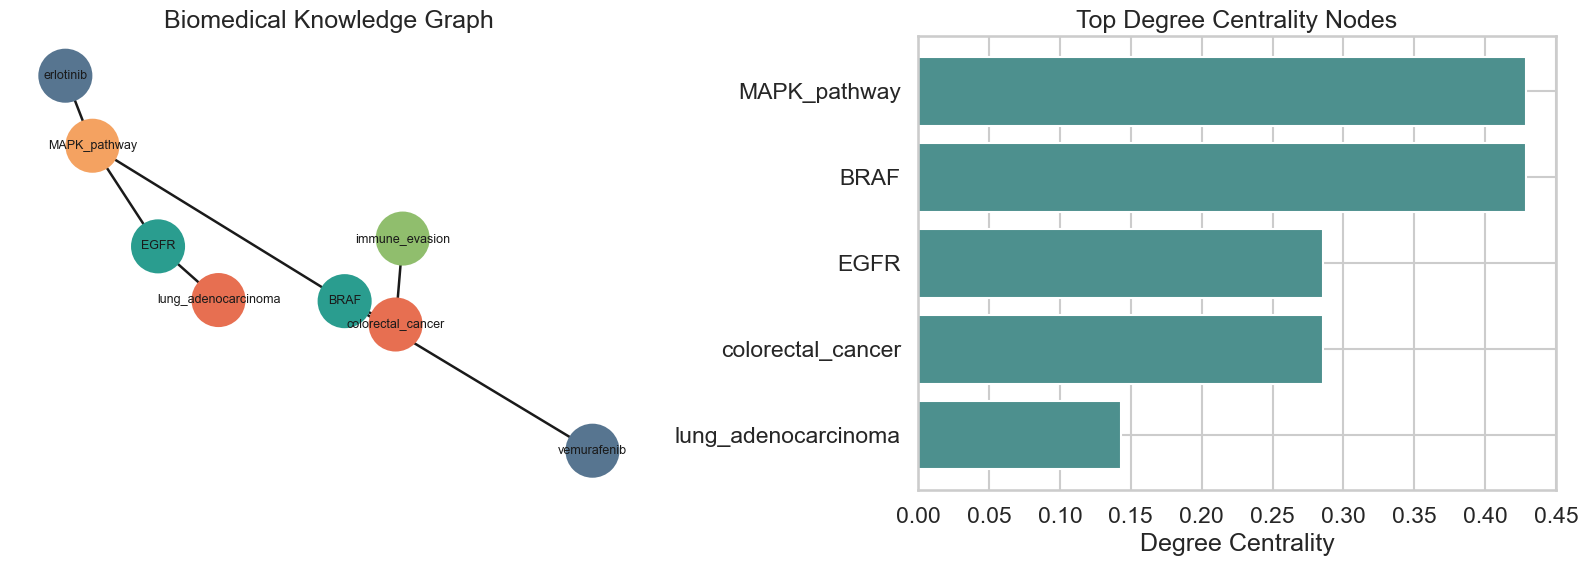

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

position = nx.spring_layout(graph, seed=42)
node_colors = nodes_df['type'].map({'disease': '#E76F51', 'gene': '#2A9D8F', 'pathway': '#F4A261', 'drug': '#577590', 'process': '#90BE6D'})

nx.draw_networkx_nodes(graph, position, node_color=node_colors.tolist(), node_size=1400, ax=axes[0])
nx.draw_networkx_edges(graph, position, arrows=True, arrowstyle='->', ax=axes[0], width=1.8)
nx.draw_networkx_labels(graph, position, font_size=9, ax=axes[0])
axes[0].set_title('Biomedical Knowledge Graph')
axes[0].axis('off')

top_nodes = centrality_df.head(5)
axes[1].barh(top_nodes['node'][::-1], top_nodes['degree_centrality'][::-1], color='#4D908E')
axes[1].set_title('Top Degree Centrality Nodes')
axes[1].set_xlabel('Degree Centrality')

plt.tight_layout()
plt.show()

## Section 5: Exercises

### Exercise 1: Bridge Node Finder

Identify the most central gene or pathway nodes that bridge disease and therapy concepts.

In [5]:
bridge_candidates = centrality_df[centrality_df['node_type'].isin(['gene', 'pathway'])].copy()
bridge_candidates = bridge_candidates.sort_values('degree_centrality', ascending=False).reset_index(drop=True)
exercise1_df = bridge_candidates.head(3)

display(exercise1_df)

,node,degree_centrality,node_type
0,MAPK_pathway,0.428571,pathway
1,BRAF,0.428571,gene
2,EGFR,0.285714,gene


### Exercise 2: Path Ranking

Rank simple disease-to-drug paths by edge weights so the strongest evidence path appears first.

In [6]:
def path_strength(path: list[str]) -> float:
    weights = []
    for source, target in zip(path, path[1:]):
        weights.append(graph[source][target]['weight'])
    return round(float(np.prod(weights)), 4)

path_rows = []
for disease, drug in [('lung_adenocarcinoma', 'erlotinib'), ('colorectal_cancer', 'vemurafenib')]:
    path = nx.shortest_path(graph, disease, drug)
    path_rows.append({'query': f'{disease} -> {drug}', 'path': ' -> '.join(path), 'path_strength': path_strength(path)})

exercise2_df = pd.DataFrame(path_rows).sort_values('path_strength', ascending=False).reset_index(drop=True)
display(exercise2_df)

,query,path,path_strength
0,colorectal_cancer -> vemurafenib,colorectal_cancer -> BRAF -> vemurafenib,0.8372
1,lung_adenocarcinoma -> erlotinib,lung_adenocarcinoma -> EGFR -> MAPK_pathway ->...,0.7524


## Section 6: Key Takeaways

- Knowledge graphs make biomedical evidence explicit and traversable.
- Centrality helps identify bridge nodes that deserve further curation.
- Path-based reasoning keeps model outputs tied to interpretable graph structure.
- Graph queries are useful for therapy matching and mechanistic hypothesis generation.
- Structured graph outputs can feed later agentic workflows and retrieval systems.


## Next Steps

1. Add ontology normalization and synonym resolution.
2. Extend the graph with patient-specific nodes and observations.
3. Connect Chapter 11 graph paths to Chapter 12 trial matching.
4. Score path evidence against curated literature snippets.


**Last Updated**: May 2026